# Методы выделения и улучшения границ

- Понятия границы и градиента яркости
- Линейная фильтрация и операция свертки
- Градиентные фильтры
- Фильтр Гаусса и гауссово сглаживание
- Детектор Кэнни
- Использование вторых производных для выделения границ
    - Фильтр Лапласа
    - Фильтр 𝐿𝑜𝐺 и метод Марра-Хилдрета
    - Фильтр 𝐷𝑜𝐺
- Нерезкое маскирование и фильтр усиления высоких частот

In [287]:
import numpy as np
import cv2
# from google.colab.patches import cv2_imshow # for image display
from IPython.display import display

from skimage import io
from PIL import Image
import matplotlib.pylab as plt

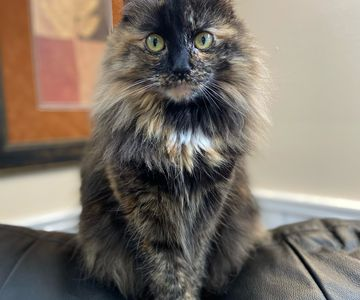

In [288]:
url = "https://placecats.com/360/300"
image = io.imread(url)  # RGB

display(Image.fromarray(image[:,:,]))

### __Границей__ (edge) называется множество пикселей, соединяющих
две области изображения с различными характеристиками
яркости

![Alt text](image-2.png)

Понятие границы тесно связано с понятием градиента яркости

$ \Huge { \nabla a(x,y) = \left( \frac{ \partial a(x,y)}{ \partial x } , \frac{ \partial a(x,y)}{ \partial y } \right) ^ T } $

Вектор градиента в точке $ (x, y) $ направлен в сторону наибольшего увеличения яркости в этой точке и перпендикулярен границе

Цифровые изображения всегда дискретны, и формально для них градиент не существует

Используются оценки градиента, например:

$ \Huge { \nabla a(x,y) \approx \begin{pmatrix} a(i,j) - a(i-1,j) \\ a(i,j) - a(i,j-1) \end{pmatrix}, 
\space i= \overline {1, M-1}; j= \overline {1, N-1} } $


Расчет градиента – локальное преобразование исходного
изображения, в результате которого получается новое
изображение, называемое градиентным изображением

Это локальное преобразование является линейным

Линейные локальные преобразования реализуются линейными
фильтрами

Линейный фильтр характеризуется некоторой матрицей 𝐾,
называемой ядром (kernel)

Применение линейного фильтра – это вычисление свёртки
изображения с матрицей 𝐾

---


### Простейший градиентный фильтр

$ \Huge { G_x = (-1,1), G_y = \begin{pmatrix} -1  \\ 1 \end{pmatrix} } $

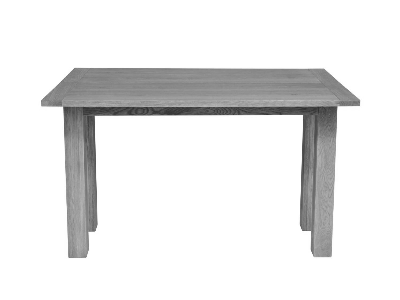

In [289]:
image = io.imread("./table.jpg")

gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
res_image = cv2.resize(gray_image, (400, 300))

display(Image.fromarray(res_image))

In [290]:
# Альтернативная библиотека
# from scipy import ndimage

# vertical = ndimage.convolve(image, kernel_x) 
# horizontal = ndimage.convolve(image, kernel_y) 

In [291]:
def to_uint8_image(image):
    res = (image - image.min()) * 255.0  / float(image.ptp()) + 0
    return res.astype(np.uint8)

In [292]:
# res_image = image

kernel_x = np.array([[-1],[1]]).T
kernel_y = np.array([[-1],[1]])

dd = cv2.CV_8U
dd = cv2.CV_16S
dd = cv2.CV_32F

# корректнее увеличивать точность
sx_gr = cv2.filter2D(res_image, dd, kernel_x, delta=0)
sy_gr = cv2.filter2D(res_image, dd, kernel_y, delta=0)

$$ 
\texttt{dst} (x,y) =  \sum _{ \substack{0\leq x' < \texttt{kernel.cols}\\{0\leq y' < \texttt{kernel.rows}}}}  \texttt{kernel} (x',y')* \texttt{src} (x+x'- \texttt{anchor.x} ,y+y'- \texttt{anchor.y} )
$$

In [293]:
# https://docs.opencv.org/4.x/d4/d86/group__imgproc__filter.html

# cv.filter2D(	src, ddepth, kernel[, dst[, anchor[, delta[, borderType]]]]	) ->	dst

# src	input image.
# dst	output image of the same size and the same number of channels as src.
# ddepth	desired depth of the destination image, see combinations
# kernel	convolution kernel (or rather a correlation kernel), a single-channel floating point matrix; if you want to apply different kernels to different channels, split the image into separate color planes using split and process them individually.
# anchor	anchor of the kernel that indicates the relative position of a filtered point within the kernel; the anchor should lie within the kernel; default value (-1,-1) means that the anchor is at the kernel center.
# delta	optional value added to the filtered pixels before storing them in dst.
# borderType	pixel extrapolation method, see BorderTypes. BORDER_WRAP is not supported.

In [294]:
kernel_x, kernel_y

(array([[-1,  1]]),
 array([[-1],
        [ 1]]))

In [295]:
print(sx_gr.min(), sx_gr.max())
print(to_uint8_image(sx_gr).min(), to_uint8_image(sx_gr).max())

-176.0 172.0
0 255


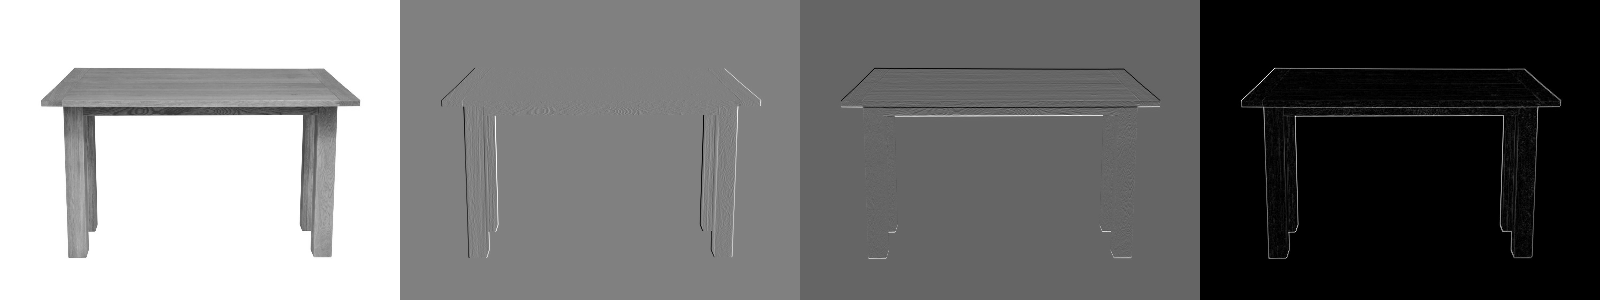

In [296]:
conc = cv2.hconcat((  res_image, to_uint8_image(sx_gr), to_uint8_image(sy_gr), 
                    to_uint8_image(abs(sx_gr)+abs(sy_gr))  ))
display(Image.fromarray(conc))

### Градиентный фильтр 2 × 2



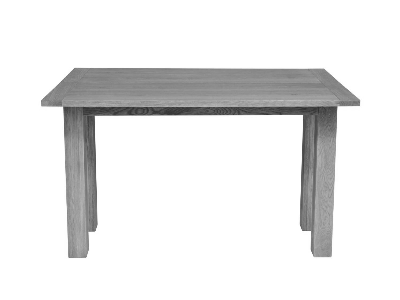

In [297]:
# url = "https://placecats.com/360/300"

# image = io.imread(url)  # RGB
image = io.imread("./table.jpg")

gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
res_image = cv2.resize(gray_image, (400, 300))

display(Image.fromarray(res_image))

![Alt text](image-3.png)

In [298]:
kernel_x = np.array([[-1, 1],
                     [-1, 1]])
kernel_y = np.array([[-1, -1],
                     [1, 1]])

dd = cv2.CV_32F
                                # dd

dx_gr = cv2.filter2D(res_image, dd, kernel_x, delta=0)
dy_gr = cv2.filter2D(res_image, dd, kernel_y, delta=0)

In [299]:
dx_gr.min(), dx_gr.max()

(-351.0, 343.0)

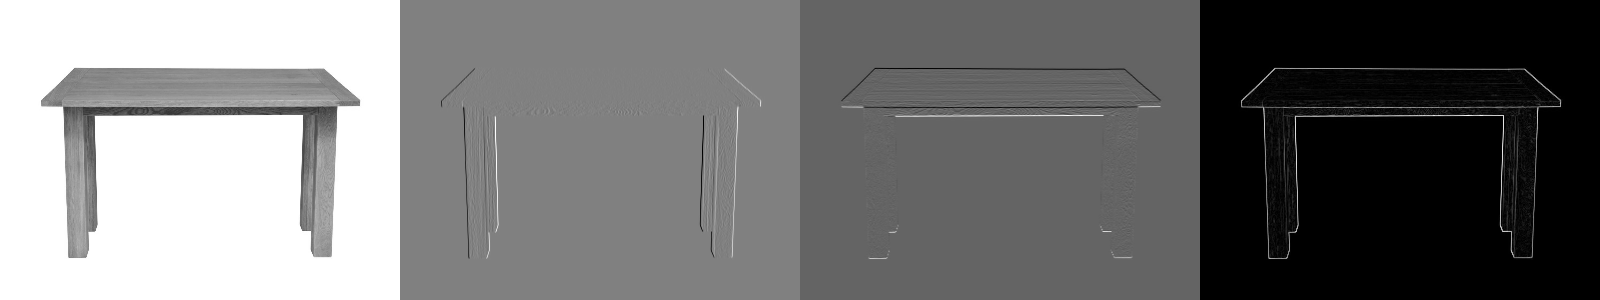

In [300]:
conc = cv2.hconcat((res_image, to_uint8_image(dx_gr), to_uint8_image(dy_gr), to_uint8_image(abs(dx_gr)+abs(dy_gr))))
display(Image.fromarray(conc))

### Оператор Робертса

![Alt text](image-4.png)

In [301]:
kernel_x = np.array([[1,  0],
                     [0, -1]])
kernel_y = np.array([[0,  1],
                     [-1, 0]])

rx_gr = cv2.filter2D(res_image, -1, kernel_x, delta=127)
ry_gr = cv2.filter2D(res_image, -1, kernel_y, delta=127)

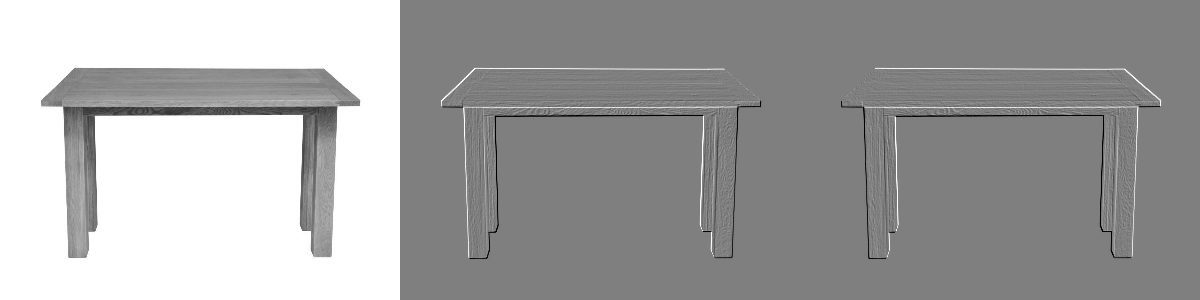

In [302]:
conc = cv2.hconcat((res_image, rx_gr, ry_gr ))
display(Image.fromarray(conc))

### Оператор Превитта, Собеля, ...

Превитта

![Alt text](image-5.png) 



Собеля

![Alt text](image-6.png)

In [303]:

#prewitt
kernel_x = np.array([[-1,0,1],
                     [-1,0,1],
                     [-1,0,1]])
kernel_y = np.array([[1,1,1],
                     [0,0,0],
                     [-1,-1,-1]])


px_gr = cv2.filter2D(res_image, -1, kernel_x, delta=127)
py_gr = cv2.filter2D(res_image, -1, kernel_y, delta=127)



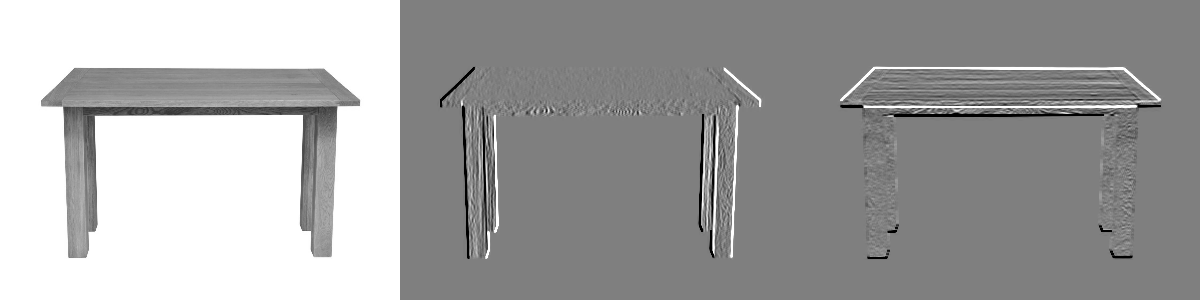

In [304]:
conc = cv2.hconcat((  res_image, px_gr, py_gr ))
display(Image.fromarray(conc))

### Оператор Собеля + Выделение границ

In [305]:
# Собель

image = io.imread("./table.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
res_image = cv2.resize(gray_image, (400, 300))

res_image = io.imread('./noisy.png', as_gray=True)

dd = cv2.CV_8U
dd = cv2.CV_16S
dd = cv2.CV_32F     # работаем на float32

sobelx_gr = cv2.Sobel(res_image, dd, 1, 0, ksize=3) # градиентные изображения float32
sobely_gr = cv2.Sobel(res_image, dd, 0, 1, ksize=3)


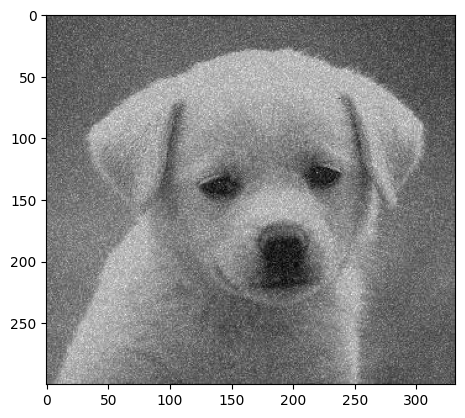

In [306]:
plt.imshow(res_image, cmap='gray')

In [307]:
sobelx_gr.min(), sobelx_gr.max()

(-370.0, 347.0)

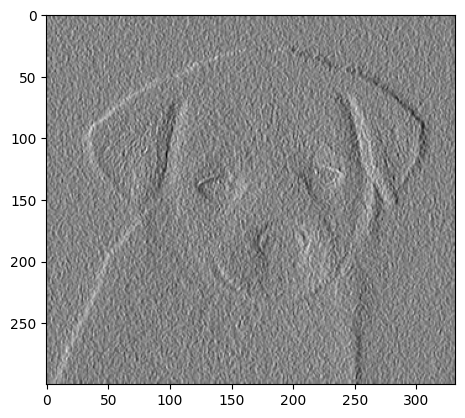

In [308]:
plt.imshow(sobelx_gr, cmap='gray')

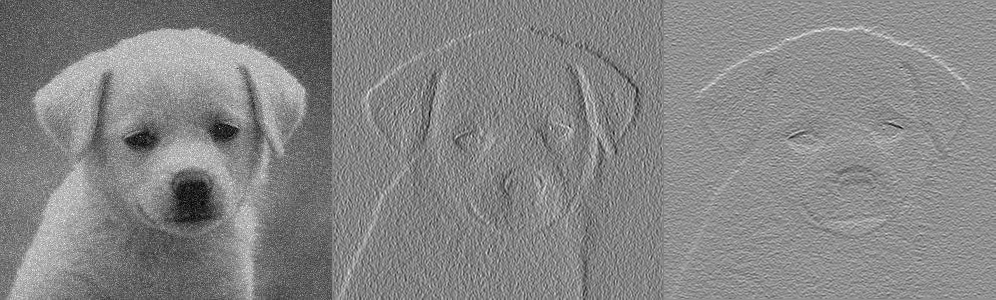

In [309]:
conc = cv2.hconcat((  res_image, to_uint8_image(sobelx_gr), to_uint8_image(sobely_gr) ))
display(Image.fromarray(conc))

(0.0, 663.3792)

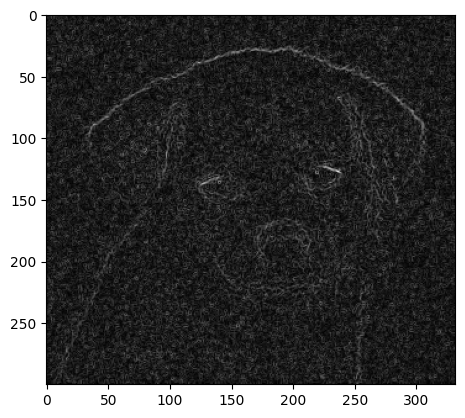

In [310]:
norm_gr = np.sqrt(sobelx_gr**2 + sobely_gr**2)      # формирование L2-нормы градиента
plt.imshow(norm_gr, cmap='gray')
norm_gr.min(), norm_gr.max()

In [311]:
norm_gr.min(), norm_gr.max(), norm_gr.mean(), norm_gr.std()

(0.0, 663.3792, 79.330444, 44.888107)

In [312]:
# ret, thr_gr = cv2.threshold(norm_gr, 100, 255, cv2.THRESH_TOZERO) # необходимо уместить в диапазон P
thr = 100
thr_gr = np.where(norm_gr < thr, thr, norm_gr)

In [313]:
thr_gr.min(), thr_gr.max(), thr_gr.mean(), thr_gr.std()

(100.0, 663.3792, 110.08143, 24.523167)

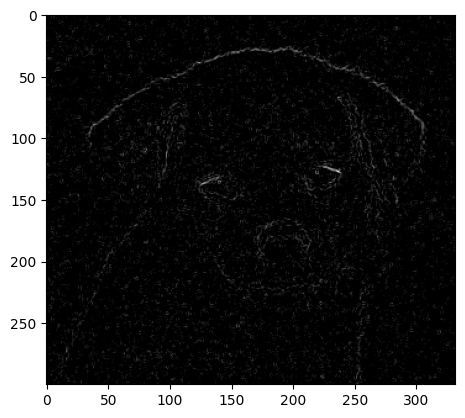

In [314]:
plt.imshow(thr_gr, cmap='gray')

### Фильтр Гаусса 

In [315]:
blurred_image = cv2.GaussianBlur(res_image, (9, 9), 1.166) # применение фильтра Гаусса


![Alt text](image-7.png)

![Alt text](image-8.png)

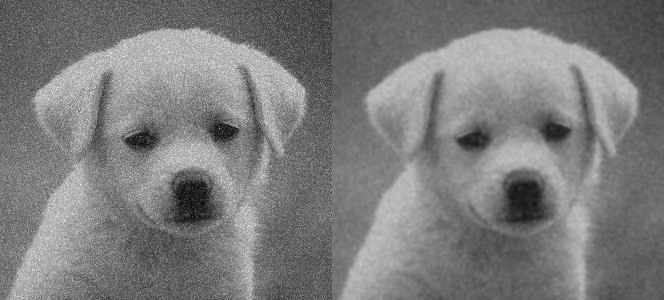

In [316]:
conc = cv2.hconcat((  res_image, blurred_image ))
display(Image.fromarray(conc))

### Детектор Кэнни (по шагам)

https://theailearner.com/tag/hysteresis-thresholding/

In [317]:
# Apply Sobelx in high output datatype 'float32'
# and then converting back to 8-bit to prevent overflow
sobelx_32 = cv2.Sobel(blurred_image,cv2.CV_32F,1,0,ksize=3)
absx_32 = np.absolute(sobelx_32)
sobelx_8u1 = absx_32/absx_32.max()*255
sobelx_8u = np.uint8(sobelx_8u1)
 
# Similarly for Sobely
sobely_32 = cv2.Sobel(blurred_image,cv2.CV_32F,0,1,ksize=3)
absy_32 = np.absolute(sobely_32)
sobely_8u1 = absy_32/absy_32.max()*255
sobely_8u = np.uint8(sobely_8u1)
 
# From gradients calculate the magnitude and changing
# it to 8-bit (Optional)
# Оно же норма градиента
mag = np.hypot(sobelx_8u, sobely_8u)
mag = mag/mag.max()*255
mag = np.uint8(mag)

# Find the direction and change it to degree
theta = np.arctan2(sobely_32, sobelx_32)
angle = np.rad2deg(theta)       # углы градиентов

![Screenshot from 2024-10-07 18-36-06.png](<attachment:Screenshot from 2024-10-07 18-36-06.png>)
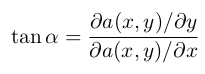

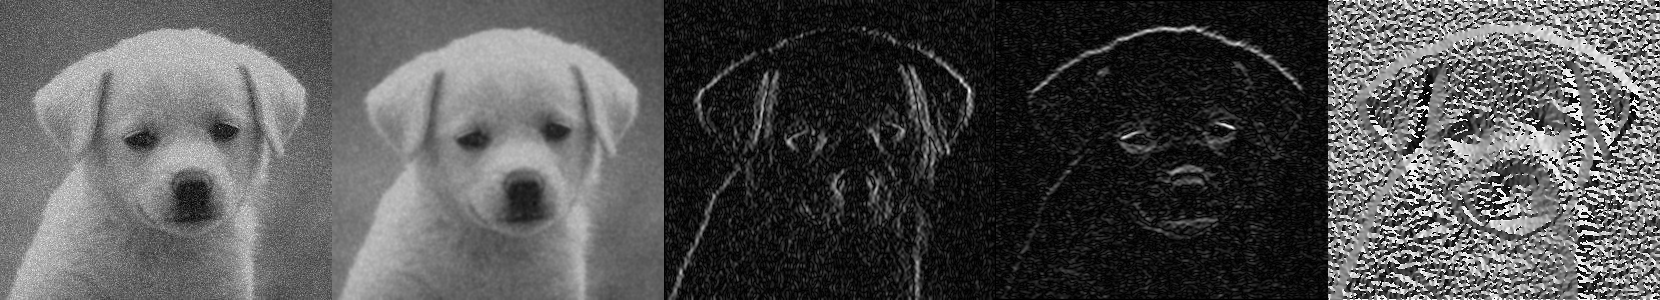

In [318]:
conc = cv2.hconcat((  res_image, blurred_image, sobelx_8u, sobely_8u, to_uint8_image(angle) ))
display(Image.fromarray(conc))

![Alt text](image-9.png)

![Alt text](image-10.png)

In [319]:
# Find the neighbouring pixels (b,c) in the rounded gradient direction
# and then apply non-max suppression
H, W = mag.shape
Non_max = np.zeros((H,W), dtype= np.uint8)
print(H, W)

for i in range(1,H-1):          # y 
    for j in range(1,W-1):      # x
       # Horizontal 0
        if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180) or (-22.5 <= angle[i,j] < 0) or (-180 <= angle[i,j] < -157.5):
            b = mag[i, j+1]
            c = mag[i, j-1]
        # Diagonal 45
        elif (22.5 <= angle[i,j] < 67.5) or (-157.5 <= angle[i,j] < -112.5):
            b = mag[i+1, j+1]
            c = mag[i-1, j-1]
        # Vertical 90
        elif (67.5 <= angle[i,j] < 112.5) or (-112.5 <= angle[i,j] < -67.5):
            b = mag[i+1, j]
            c = mag[i-1, j]
        # Diagonal 135
        elif (112.5 <= angle[i,j] < 157.5) or (-67.5 <= angle[i,j] < -22.5):
            b = mag[i+1, j-1]
            c = mag[i-1, j+1]           
            
        # Non-max Suppression
        if (mag[i,j] >= b) and (mag[i,j] >= c):
            Non_max[i,j] = mag[i,j]
        else:
            Non_max[i,j] = 0

300 332


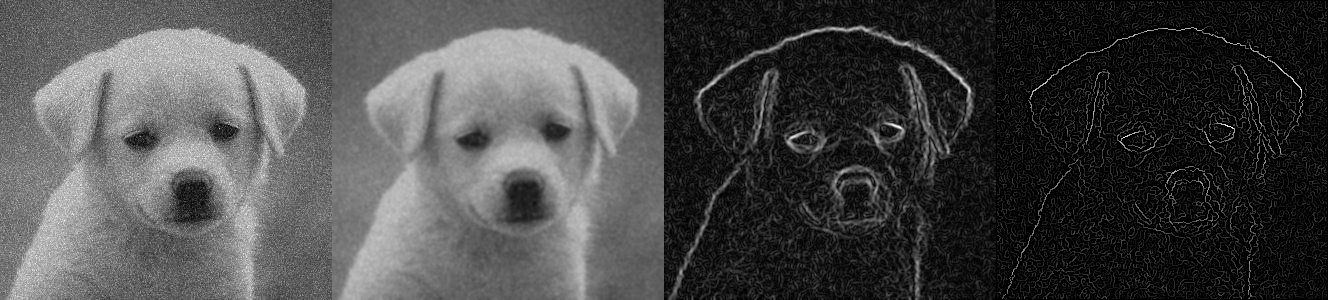

In [320]:
conc = cv2.hconcat((  res_image, blurred_image, mag, Non_max ))
display(Image.fromarray(conc))

In [321]:
# Set high and low threshold
highThreshold = 75   
lowThreshold = 40

H, W = Non_max.shape
out = np.zeros((H,W), dtype= np.uint8)
 
# If edge intensity is greater than 'High' it is a sure-edge
# below 'low' threshold, it is a sure non-edge
strong_i, strong_j = np.where(Non_max >= highThreshold)
zeros_i, zeros_j = np.where(Non_max < lowThreshold)
 
# weak edges
weak_i, weak_j = np.where((Non_max <= highThreshold) & (Non_max >= lowThreshold))
 
# Set same intensity value for all edge pixels
out[strong_i, strong_j] = 255
out[zeros_i, zeros_j ] = 0
out[weak_i, weak_j] = 75


H, W = out.shape
for i in range(1, H-1):
    for j in range(1, W-1):
        if (out[i,j] == 75):
            if 255 in [out[i+1, j-1],out[i+1, j],out[i+1, j+1],out[i, j-1],out[i, j+1],out[i-1, j-1],out[i-1, j],out[i-1, j+1]]:
                out[i, j] = 255
            else:
                out[i, j] = 0

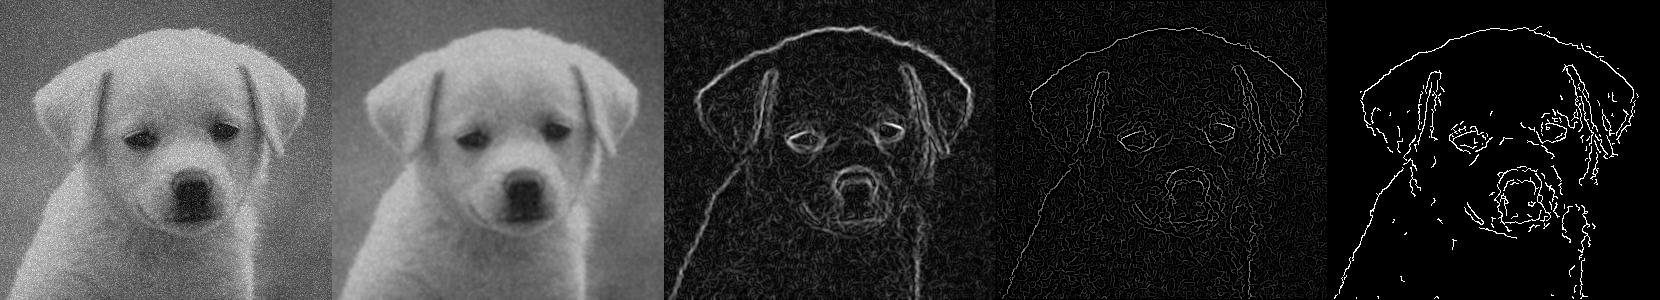

In [322]:
conc = cv2.hconcat((  res_image, blurred_image, mag, Non_max, out ))
display(Image.fromarray(conc))

In [323]:
#canny
canny_image = cv2.Canny(blurred_image, 40, 75, L2gradient=True)

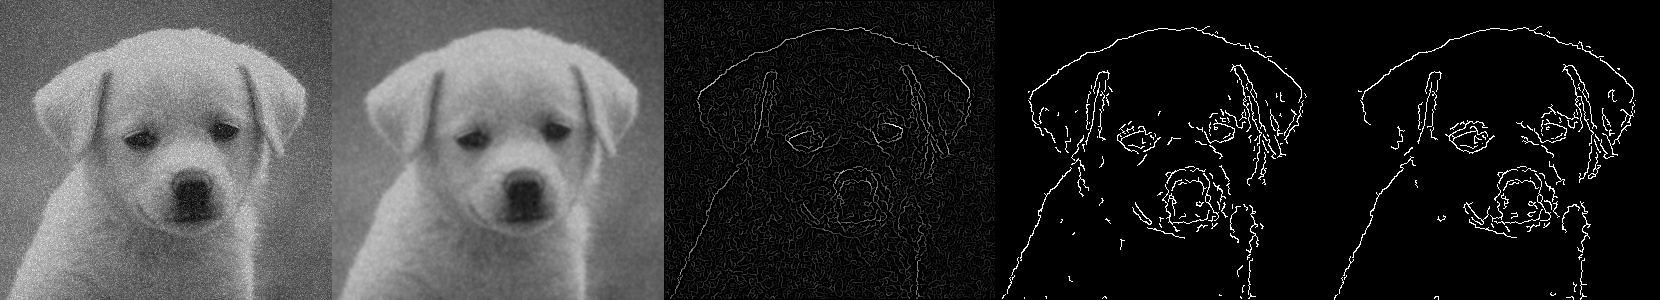

In [324]:
conc = cv2.hconcat((  res_image, blurred_image, Non_max, out, canny_image ))
display(Image.fromarray(conc))

In [325]:
# mean = 0
# stddev = 50
# noise = np.zeros(res_image.shape, np.uint8)
# noise = cv2.randn(noise, mean, stddev)
# noisy_img = cv2.add(res_image, noise)

# sobelx_gr = cv2.Sobel(noisy_img, dd, 1, 0, ksize=3) # градиентные изображения float32
# sobely_gr = cv2.Sobel(noisy_img, dd, 0, 1, ksize=3)

# conc = cv2.hconcat((  noisy_img, to_uint8_image(sobelx_gr), to_uint8_image(sobely_gr) ))
# display(Image.fromarray(conc))

### Использование вторых производных

В точках, где вторая производная равна нулю, первая
производная принимает экстремальное значение

Для второй производной вместо отслеживания пересечения
порога, требуется отслеживание пересечения нулевого значения
(zero crossings)

![Alt text](image-11.png)

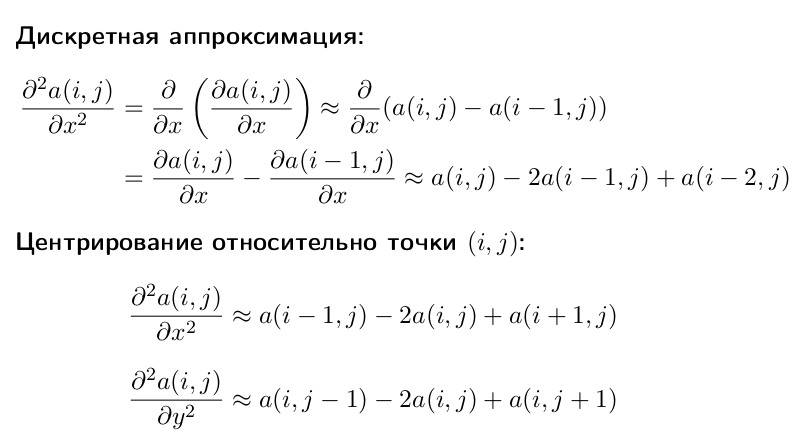

![Screenshot from 2024-10-07 17-26-28.png](<attachment:Screenshot from 2024-10-07 17-26-28.png>)
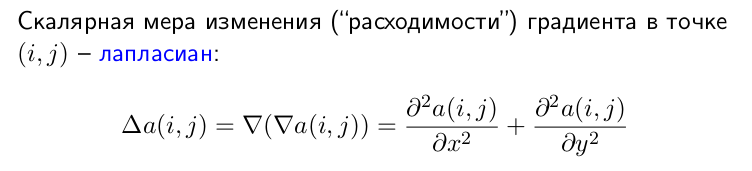

In [354]:
url = "https://placecats.com/360/360"
res_image = io.imread(url)  # RGB
res_image = cv2.cvtColor(res_image, cv2.COLOR_RGB2GRAY)

# res_image = io.imread('./noisy.png', as_gray=True)

# res_image = io.imread('./dog2.jpg')
# res_image = cv2.cvtColor(res_image, cv2.COLOR_RGB2GRAY)
# res_image = cv2.resize(res_image, (300,300))

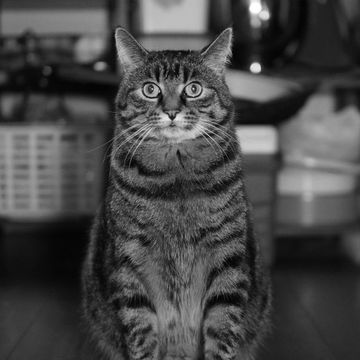

In [355]:
display(Image.fromarray(res_image))

In [356]:
res_image.max(), res_image.min(), res_image.shape

(255, 0, (360, 360))

![Alt text](<Screenshot from 2023-10-25 20-11-16.png>)

![Screenshot from 2024-10-07 17-28-27.png](<attachment:Screenshot from 2024-10-07 17-28-27.png>)
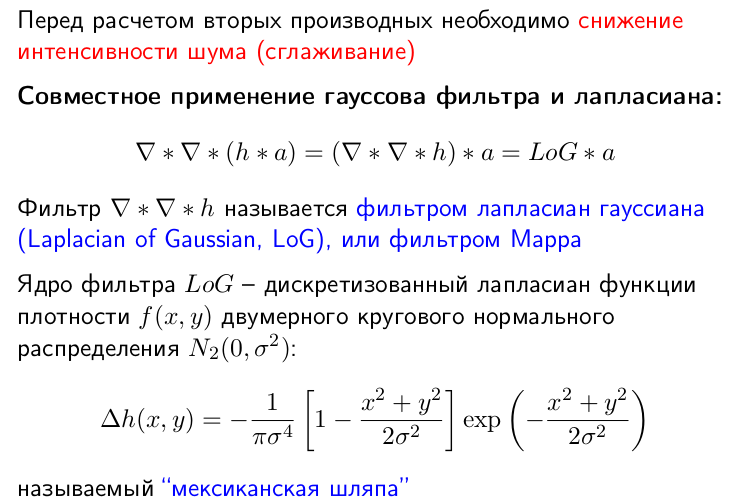

In [357]:
ddepth = cv2.CV_16S
kernel_size = 5

# Remove noise by blurring with a Gaussian filter
blurred_image = cv2.GaussianBlur(res_image, (5, 5), 1.0)
# blurred_image = res_image

# Apply Laplace function
lap_image = cv2.Laplacian(blurred_image, ddepth, ksize=kernel_size)
# filter2D()

lap_image_ui8 = to_uint8_image(lap_image)


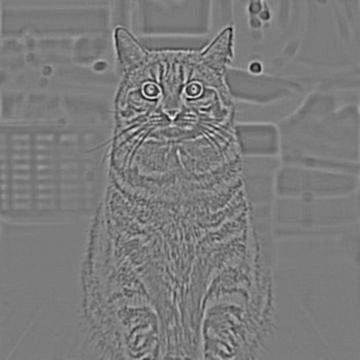

In [358]:
display(Image.fromarray(lap_image_ui8))

In [359]:
lap_image.max(), lap_image.min()

(2440, -2314)

In [360]:
def zero_crossing(image):
    z_c_image = np.zeros(image.shape)
    
    # For each pixel, count the number of positive
    # and negative pixels in the neighborhood
    
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            negative_count = 0
            positive_count = 0
            neighbour = [image[i+1, j-1],image[i+1, j],image[i+1, j+1],image[i, j-1],image[i, j+1],image[i-1, j-1],image[i-1, j],image[i-1, j+1]]
            d = max(neighbour)
            e = min(neighbour)
            for h in neighbour:
                if h>0:
                    positive_count += 1
                elif h<0:
                    negative_count += 1
 
 
            # If both negative and positive values exist in 
            # the pixel neighborhood, then that pixel is a 
            # potential zero crossing
            
            z_c = ((negative_count > 1) and (positive_count > 1))
            
            # Change the pixel value with the maximum neighborhood
            # difference with the pixel
 
            if z_c:
                if image[i,j]>0:
                    z_c_image[i, j] = image[i,j] + np.abs(e)
                elif image[i,j]<0:
                    z_c_image[i, j] = np.abs(image[i,j]) + d
                
    # Normalize and change datatype to 'uint8' (optional)
    z_c_norm = z_c_image/z_c_image.max()*255
    z_c_image = np.uint8(z_c_norm)
 
    return z_c_image

In [361]:
zc_image = zero_crossing(lap_image)

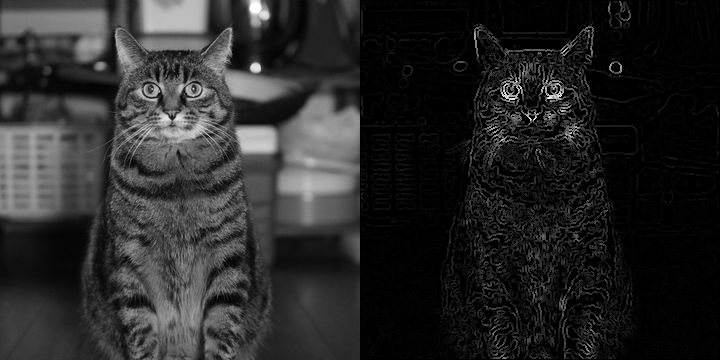

In [362]:
conc = cv2.hconcat((  res_image, zc_image ))
display(Image.fromarray(conc))

In [366]:
highThreshold = 60
lowThreshold = 20

H, W = zc_image.shape
out = np.zeros((H,W), dtype= np.uint8)

strong_i, strong_j = np.where(zc_image >= highThreshold)
zeros_i, zeros_j = np.where(zc_image < lowThreshold)
weak_i, weak_j = np.where((zc_image <= highThreshold) & (zc_image >= lowThreshold))
 
# Set same intensity value for all edge pixels
out[strong_i, strong_j] = 255
out[zeros_i, zeros_j ] = 0
out[weak_i, weak_j] = 75

out_pre = out.copy()

H, W = out.shape
for i in range(1, H-1):
    for j in range(1, W-1):
        if (out[i,j] == 75):
            nbhd = [out[i+1, j-1],out[i+1, j],out[i+1, j+1],out[i, j-1],out[i, j+1],out[i-1, j-1],out[i-1, j],out[i-1, j+1]]
            if nbhd.count(255) >= 2 :
                out[i, j] = 255
            else:
                out[i, j] = 0


In [367]:
zc_image.min(), zc_image.max(), out.min(), out.max(), out.shape

(0, 255, 0, 255, (360, 360))

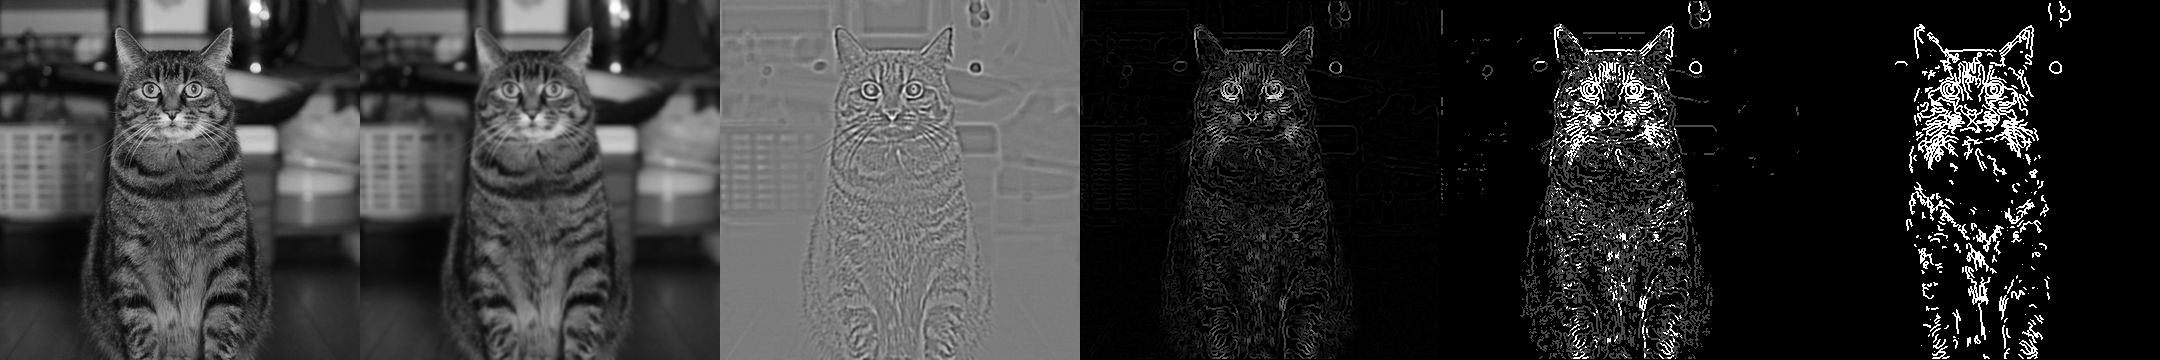

In [368]:
conc = cv2.hconcat((  res_image, blurred_image, lap_image_ui8, zc_image, out_pre, out))
display(Image.fromarray(conc))

In [369]:
def edgesMarrHildreth(img, sigma):
    """
            finds the edges using MarrHildreth edge detection method...
            :param im : input image
            :param sigma : sigma is the std-deviation and refers to the spread of gaussian
            :return:
            a binary edge image...
    """
    size = int(2*(np.ceil(3*sigma))+1)

    x, y = np.meshgrid(np.arange(-size/2+1, size/2+1),
                       np.arange(-size/2+1, size/2+1))

    normal = 1 / (2.0 * np.pi * sigma**2)

    kernel = ((x**2 + y**2 - (2.0*sigma**2)) / sigma**4) * \
        np.exp(-(x**2+y**2) / (2.0*sigma**2)) / normal  # LoG filter

    print(kernel.shape)
    kern_size = kernel.shape[0]
    log = np.zeros_like(img, dtype=float)

    # applying filter
    for i in range(img.shape[0]-(kern_size-1)):
        for j in range(img.shape[1]-(kern_size-1)):
            window = img[i:i+kern_size, j:j+kern_size] * kernel
            log[i, j] = np.sum(window)

    log = log.astype(np.int64, copy=False)

    zero_crossing = np.zeros_like(log)

    # computing zero crossing
    for i in range(log.shape[0]-(kern_size-1)):
        for j in range(log.shape[1]-(kern_size-1)):
            if log[i][j] == 0:
                if (log[i][j-1] < 0 and log[i][j+1] > 0) or (log[i][j-1] < 0 and log[i][j+1] < 0) or (log[i-1][j] < 0 and log[i+1][j] > 0) or (log[i-1][j] > 0 and log[i+1][j] < 0):
                    zero_crossing[i][j] = 255
            if log[i][j] < 0:
                if (log[i][j-1] > 0) or (log[i][j+1] > 0) or (log[i-1][j] > 0) or (log[i+1][j] > 0):
                    zero_crossing[i][j] = 255

    # plotting images
    fig = plt.figure()
    a = fig.add_subplot(1, 2, 1)
    imgplot = plt.imshow(log, cmap='gray')
    a.set_title('Laplacian of Gaussian')
    a = fig.add_subplot(1, 2, 2)
    imgplot = plt.imshow(zero_crossing, cmap='gray')
    string = 'Zero Crossing sigma = '
    string += (str(sigma))
    a.set_title(string)
    plt.show()

    return log, zero_crossing

(7, 7)


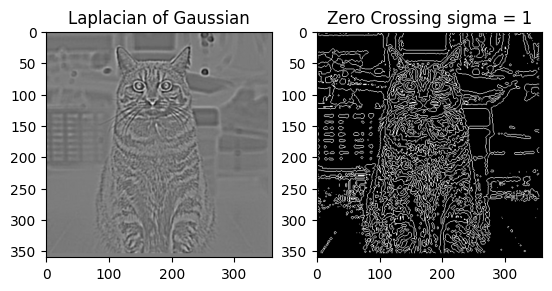

In [ ]:
mh_image = edgesMarrHildreth(blurred_image, 1)

### Разность двумерных гауссиан DoG

Мексиканская шляпа может быть аппроксимирована разностью
двух функций плотности нормального распределения с
разными дисперсиями 𝜎12 и 𝜎22

![Alt text](<Screenshot from 2023-10-25 20-22-47.png>)

![Screenshot from 2024-10-07 19-06-43.png](<attachment:Screenshot from 2024-10-07 19-06-43.png>)
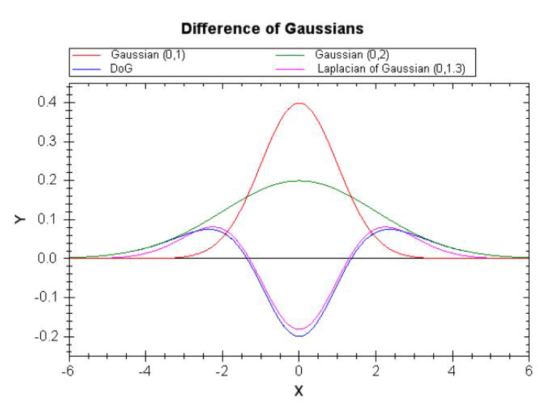

In [375]:
url = "https://placecats.com/300/300"
res_image = io.imread(url)  # RGB
res_image = cv2.cvtColor(res_image, cv2.COLOR_RGB2GRAY)

In [377]:
sigma1 = 2
k = 1.6
sigma2 = sigma1 / k 
# Apply 3x3 and 7x7 Gaussian blur
low_sigma = cv2.GaussianBlur(res_image, (3,3), sigma2)
high_sigma = cv2.GaussianBlur(res_image, (3,3), sigma1)

# Calculate the DoG by subtracting
dog = low_sigma - high_sigma

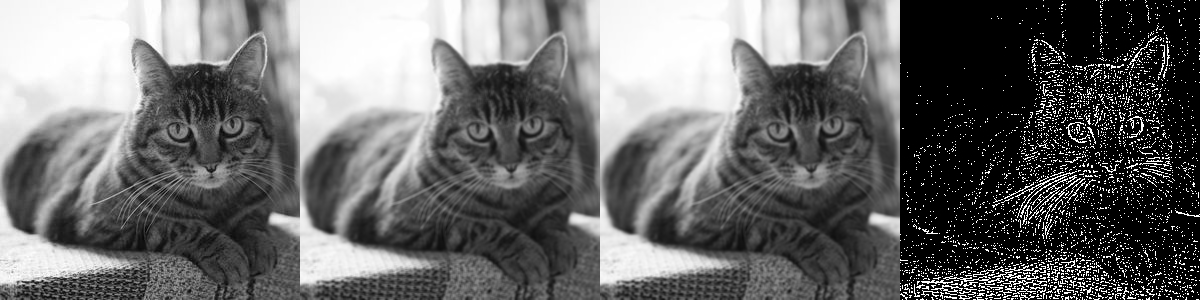

In [378]:
conc = cv2.hconcat((  res_image, high_sigma, low_sigma, dog))
display(Image.fromarray(conc))

### Нерезкое маскирование изображения / Фильтр усиления высоких частот

In [380]:
url = "https://placecats.com/300/320"
res_image = io.imread(url)  # RGB
res_image = cv2.cvtColor(res_image, cv2.COLOR_RGB2GRAY)

Изображение с усиленной высокочастотной компонентой

𝑔 = 𝑎 + 𝜆𝑑 = 𝑎 + 𝜆(𝑎 − 𝑎
˜)

In [381]:
gauss = cv2.GaussianBlur(res_image, (3,3), 1.0)
diff = res_image.astype(np.float32) - gauss

In [382]:
# diff = np.where(abs(diff) > 10, diff, 0 )

diff.min(), diff.max()

(-67.0, 82.0)

In [383]:
diff_ui8 = to_uint8_image(diff)
um_image = res_image + 1.2 * diff
um_image_ui8 = to_uint8_image(um_image)
um_image.min(), um_image.max()

(-59.0, 285.8)

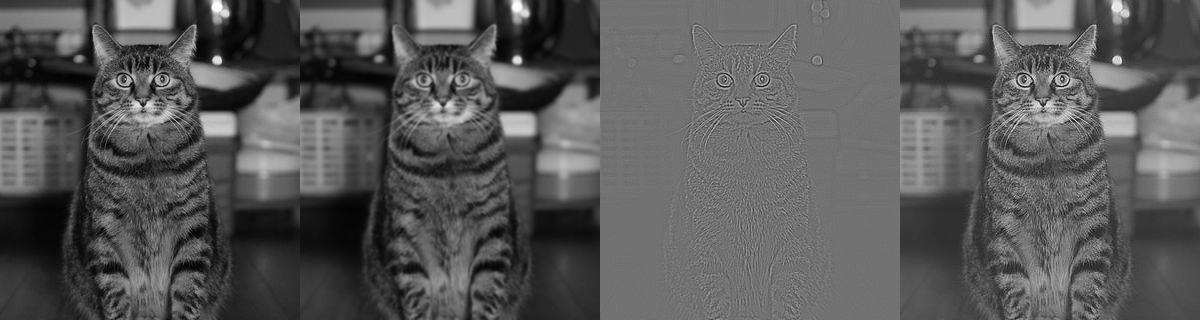

In [347]:
conc = cv2.hconcat((  res_image, gauss, diff_ui8, um_image_ui8))
display(Image.fromarray(conc))

Фильтр усиления высоких частот

𝑔 = 𝑎 − 𝜆Δ𝑎 = 𝑎 − 𝜆(Δ * 𝑎) = (1 − 𝜆Δ) * 𝑎 = ℎ * 𝑎

In [384]:
# Calculate the Laplacian
lap = cv2.Laplacian(res_image, cv2.CV_32F, ksize=3)

ker1 = np.array([[0,0,0],[0,1,0],[0,0,0]])
ker2 = np.array([[0,1,0],[1,-4,1],[0,1,0]])

lam = 0.2
hf_ker = ker1 - lam * ker2

hf_image = cv2.filter2D(res_image, cv2.CV_32F, hf_ker)
# Calculate the sharpened image
sharp = res_image - 0.1*lap

lap_ui8 = to_uint8_image(lap)
sharp_ui8 = to_uint8_image(sharp)
hf_ui8 = to_uint8_image(hf_image)

In [385]:
hf_ker

array([[ 0. , -0.2,  0. ],
       [-0.2,  1.8, -0.2],
       [ 0. , -0.2,  0. ]])

In [386]:
sharp.min(), sharp.max()

(-61.200005, 285.6)

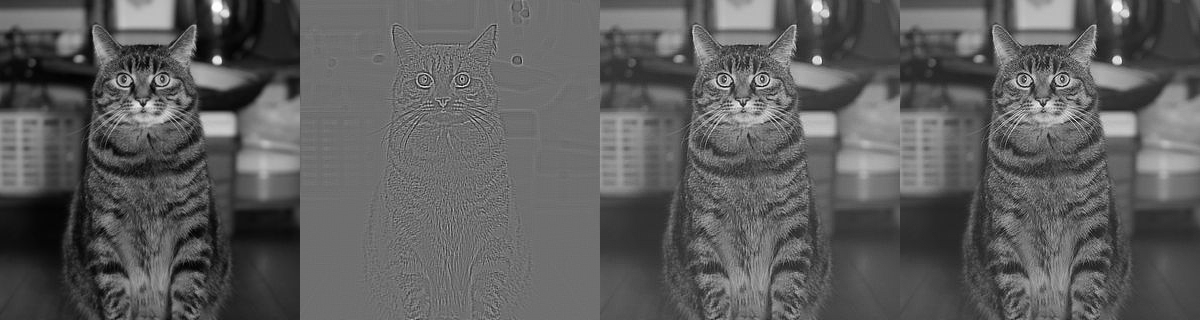

In [387]:
conc = cv2.hconcat((  res_image, lap_ui8, sharp_ui8, hf_ui8))
display(Image.fromarray(conc))